In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-10-05

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.17.1

debugpy: 1.8.22



## Librerias

In [2]:
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
import statsmodels.api as sm
import pingouin as pg
from pathlib import Path
ruta_base = Path.cwd()
ruta_base

WindowsPath('C:/Users/ManuelOrellana/Desktop/Proyectos Aplicaciones/Aplicacion Prediccion Productos/Creacion de Modelos/Analisis y entrenamiento de modelos')

## Dataset

In [3]:
df = pl.scan_parquet(ruta_base/ "Datasets/Concatenados/Limpios/train2.parquet").collect(engine="streaming")
df.head(3)

ID,fecha,numero_tienda,numero_articulo,ciudad,provincia_estado,tipo_tienda,cluster,familia_producto,clase_producto,perecedero,precio_petroleo_wti,es_feriado_nacional,es_evento,es_feriado_regional,es_feriado_local,transacciones,en_promocion,unidades_vendidas,año,mes,semana,dia_semana,dia,mes_radianes,dia_semana_radianes,semana_radianes,mes_seno,mes_coseno,dia_semana_seno,dia_semana_coseno,semana_seno,semana_coseno,es_quincena,venta_grande,Se vende,unidades_vendidas_ayer,unidades_vendidas_promedio_semanal,petroleo_promedio_3meses
u32,date,i8,i32,cat,cat,cat,i8,cat,i16,i8,f32,i8,i8,i8,i8,f32,i8,f32,i16,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,i8,i8,i8,f32,f32,f32
1104603,2013-01-29,13,1036317,"""Latacunga""","""Cotopaxi""","""C""",15,"""CLEANING""",3018,0,97.620003,0,0,0,0,884.0,0,3.0,2013,1,5,2,29,0.523599,1.795196,0.592753,0.5,0.866025,0.974928,-0.222521,0.558647,0.829406,0,0,1,2.0,4.285714,94.291847
1072754,2013-01-28,27,268664,"""Daule""","""Guayas""","""D""",1,"""GROCERY I""",1028,0,95.949997,0,0,0,0,1052.0,0,5.0,2013,1,5,1,28,0.523599,0.897598,0.592753,0.5,0.866025,0.781832,0.62349,0.558647,0.829406,0,0,1,4.0,2.428571,94.228073
1038482,2013-01-27,38,318787,"""Loja""","""Loja""","""D""",4,"""GROCERY I""",1040,0,95.150002,0,0,0,0,2331.0,0,2.0,2013,1,4,7,27,0.523599,6.283185,0.474203,0.5,0.866025,1.7485e-7,1.0,0.456629,0.889657,0,0,1,10.0,7.285714,94.1912


## Gráficas

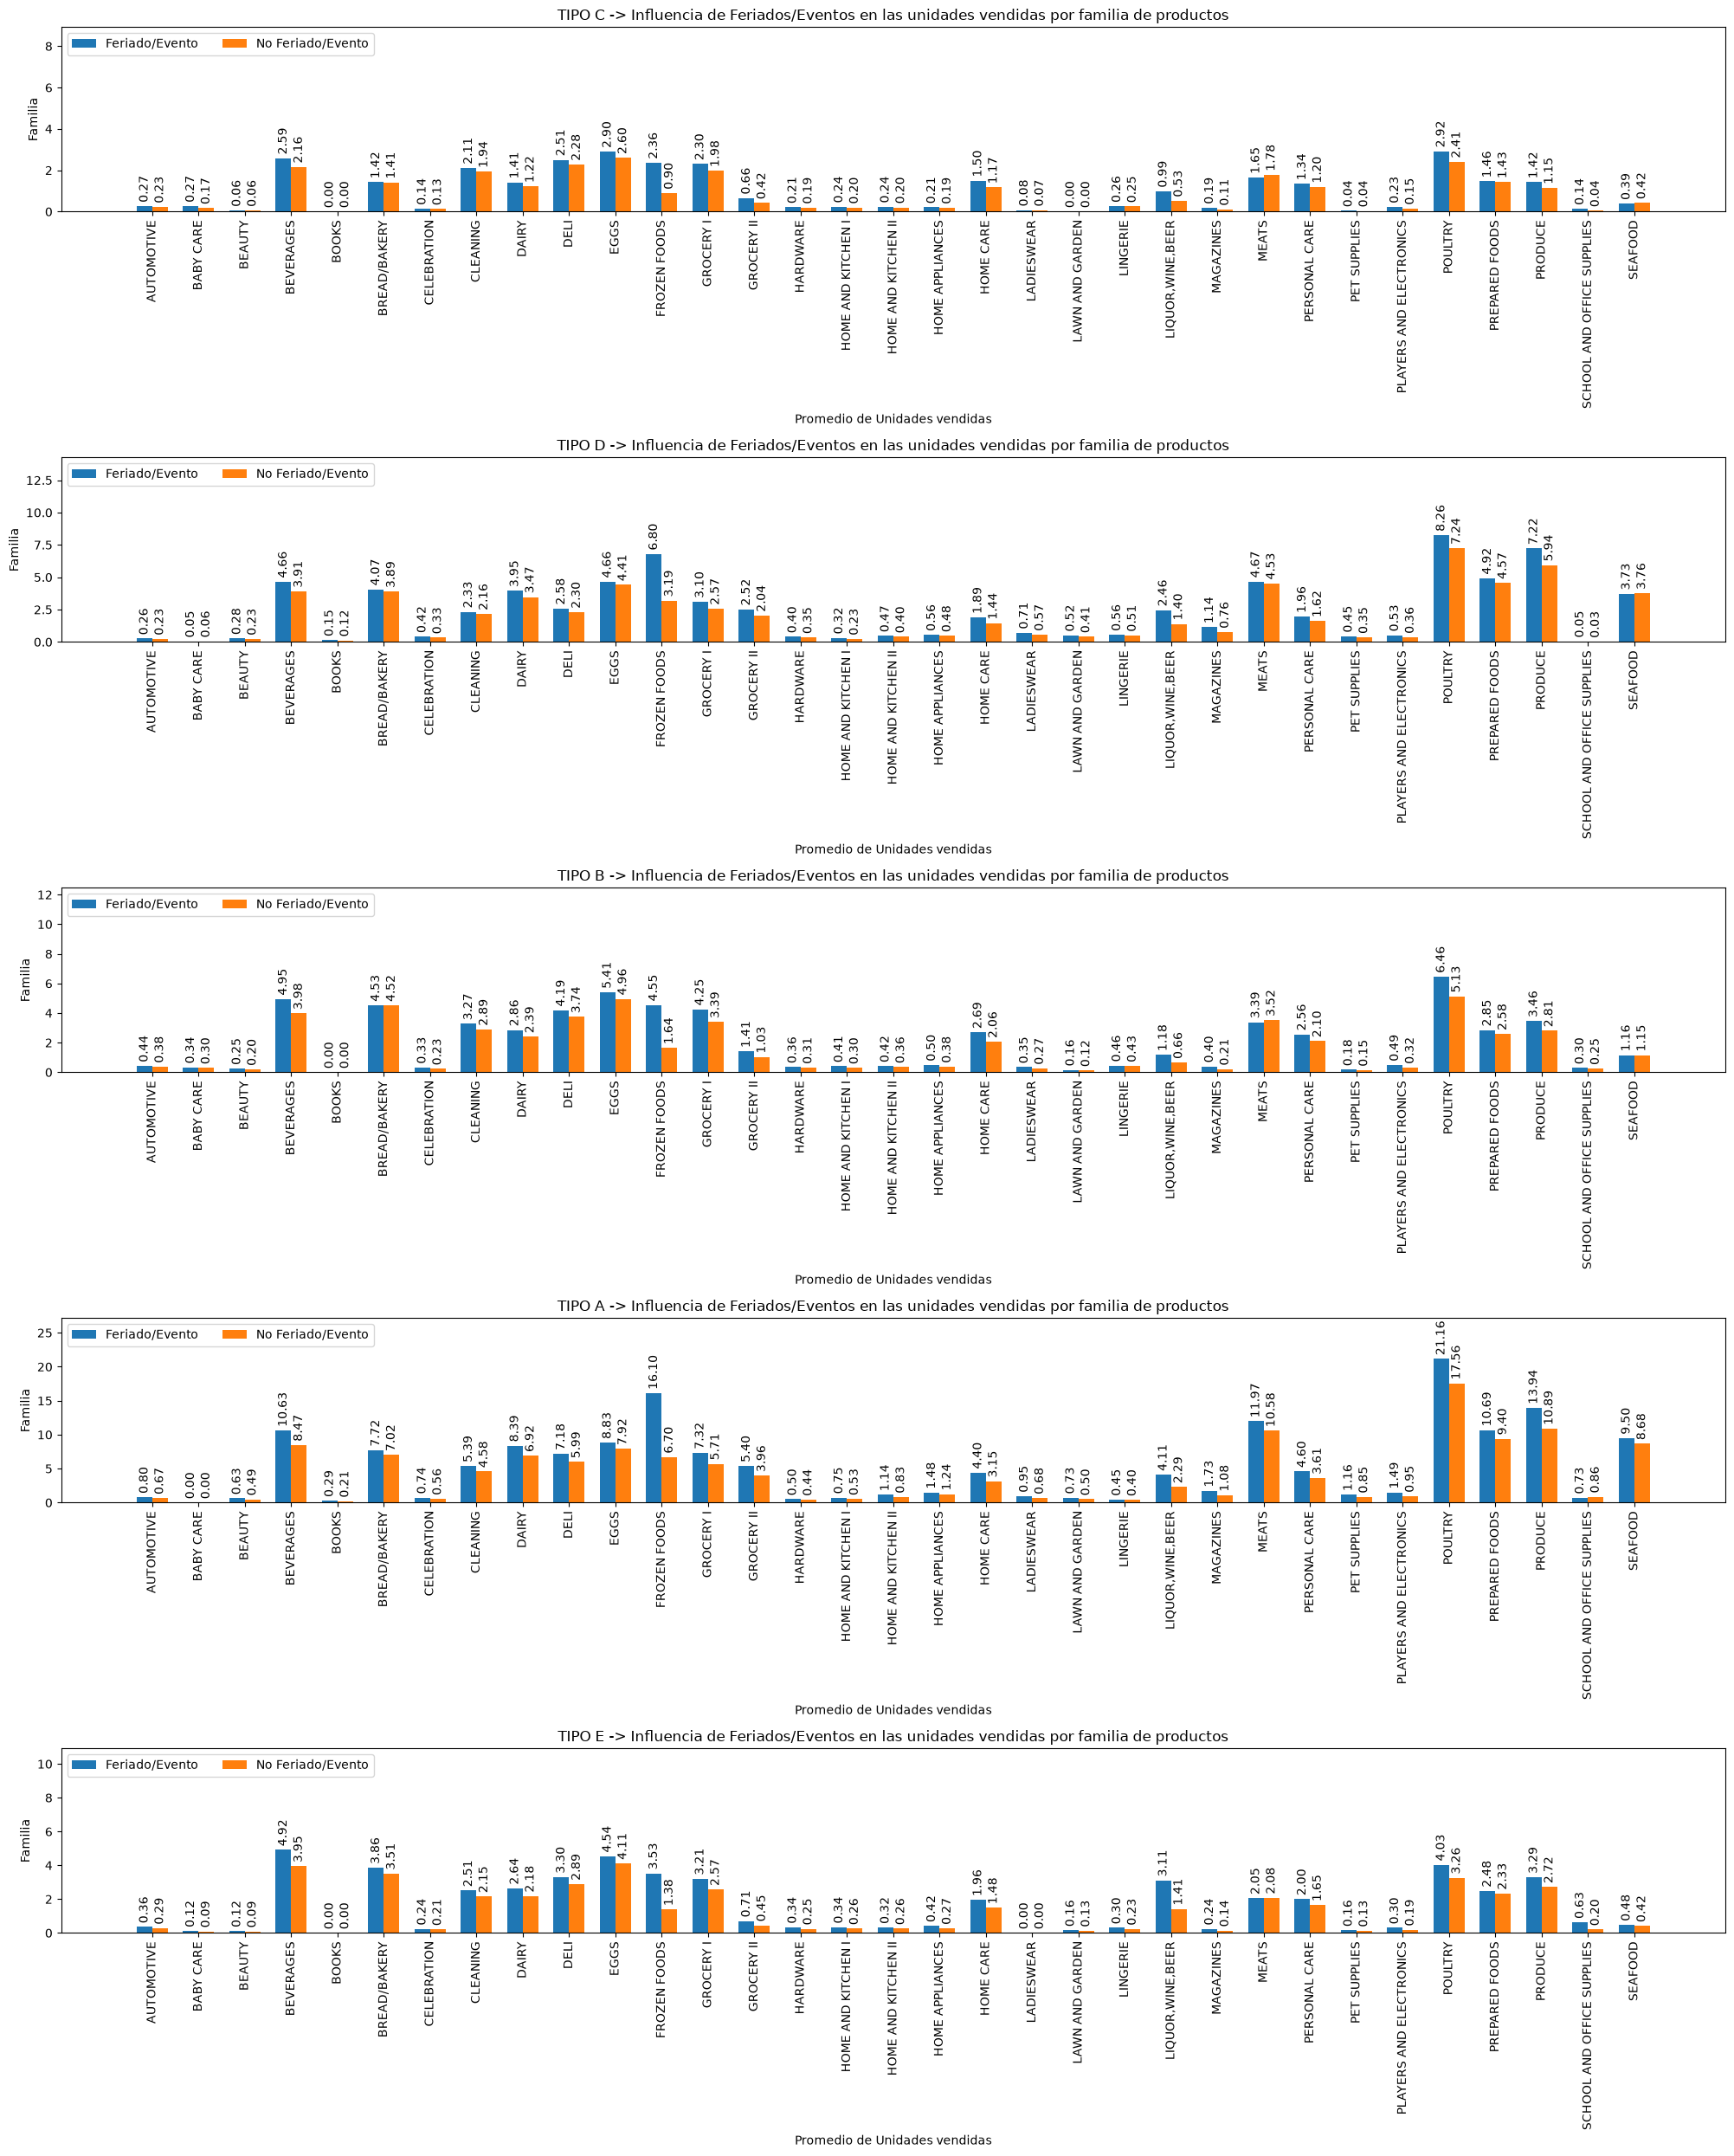

In [4]:
tipos_tiendas = df.select(pl.col("tipo_tienda").unique()).to_series().to_list()
familias_productos = df.select(pl.col("familia_producto").unique()).to_series().to_list()
fig, axes = plt.subplots(nrows= len(tipos_tiendas), figsize=(20, 25))

df_temporal = df.select(["tipo_tienda", "familia_producto", "unidades_vendidas", "es_feriado_nacional", "es_feriado_regional", "es_feriado_local", "es_evento"])

for ax in range(len(tipos_tiendas)):
    df_tipo_tienda_temporal = df_temporal.filter(pl.col("tipo_tienda") == tipos_tiendas[ax])
    familias_productos = sorted(df_tipo_tienda_temporal.select(pl.col("familia_producto").unique()).to_series().to_list())

    df_temporal_feriado_evento= df_tipo_tienda_temporal.filter((pl.col("es_feriado_nacional") |  pl.col("es_feriado_regional") | pl.col("es_feriado_local") | pl.col("es_evento")) == 1)
    df_temporal_no_feriado_evento = df_tipo_tienda_temporal.filter((pl.col("es_feriado_nacional") |  pl.col("es_feriado_regional") | pl.col("es_feriado_local") | pl.col("es_evento")) == 0)

    diccionario_temporal = {
        "Feriado/Evento" : [],
        "No Feriado/Evento" : []
    }

    for familia in familias_productos:
        promedio_unidades_feriado_evento = (
            df_temporal_feriado_evento
            .filter(pl.col("familia_producto") == familia)
            .select(pl.col("unidades_vendidas").mean())
            .item()
        )

        promedio_unidades_no_feriado_evento = (
            df_temporal_no_feriado_evento
            .filter(pl.col("familia_producto") == familia)
            .select(pl.col("unidades_vendidas").mean())
            .item()
        )

        diccionario_temporal["Feriado/Evento"].append(promedio_unidades_feriado_evento)
        diccionario_temporal["No Feriado/Evento"].append(promedio_unidades_no_feriado_evento)

    grafico = axes[ax].grouped_bar(diccionario_temporal, tick_labels=familias_productos, group_spacing=1)
    for barra in grafico.bar_containers:
        axes[ax].bar_label(barra, padding=3, rotation=90, fmt="%.2f")

    axes[ax].set_title(f"TIPO {tipos_tiendas[ax]} -> Influencia de Feriados/Eventos en las unidades vendidas por familia de productos")
    axes[ax].set_ylabel("Familia")
    axes[ax].set_xlabel("Promedio de Unidades vendidas")
    axes[ax].tick_params(axis="x", rotation=90)
    axes[ax].legend(loc='upper left', ncols=2)
    axes[ax].set_ylim(0, max(max(diccionario_temporal["Feriado/Evento"])+6, max(diccionario_temporal["No Feriado/Evento"])+6) )

plt.tight_layout()
plt.show()

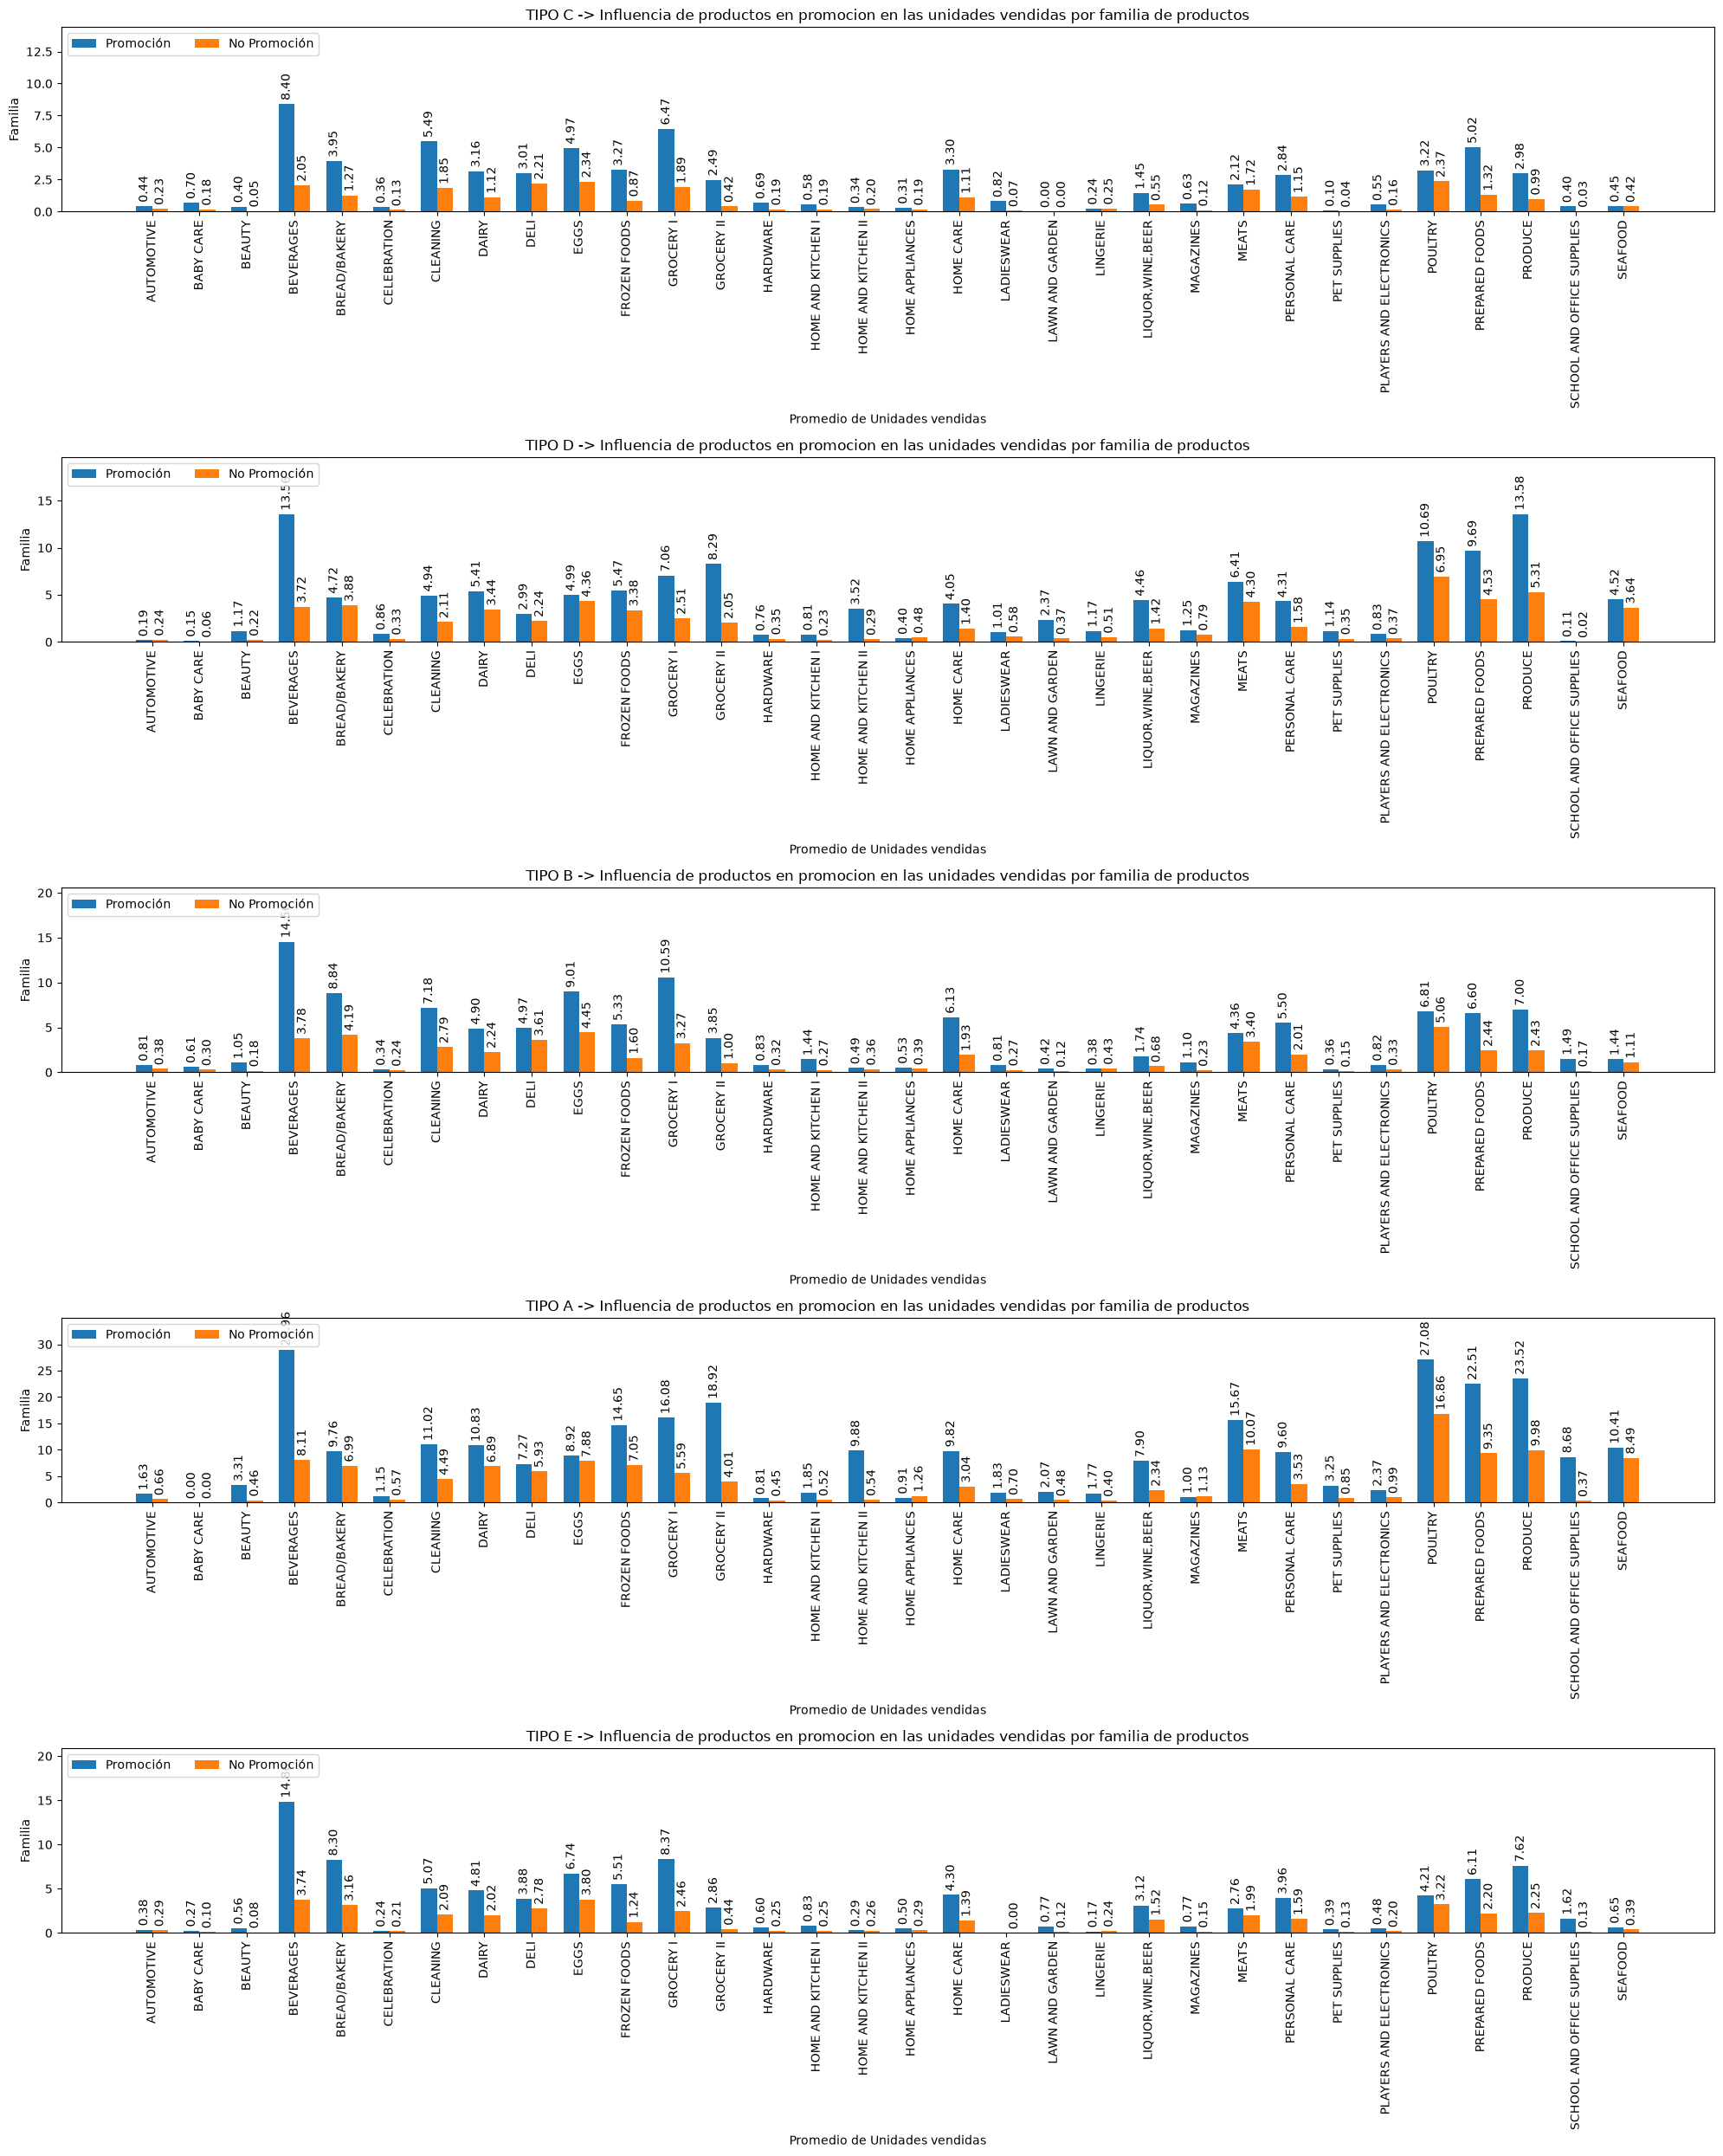

In [5]:
tipos_tiendas = df.select(pl.col("tipo_tienda").unique()).to_series().to_list()
familias_productos = df.select(pl.col("familia_producto").unique()).to_series().to_list()
fig, axes = plt.subplots(nrows= len(tipos_tiendas), figsize=(20, 25))

df_temporal = df.select(["tipo_tienda", "familia_producto", "unidades_vendidas", "en_promocion"])

for ax in range(len(tipos_tiendas)):
    df_tipo_tienda_temporal = df_temporal.filter(pl.col("tipo_tienda") == tipos_tiendas[ax])
    familias_productos = sorted(df_tipo_tienda_temporal.select(pl.col("familia_producto").unique()).to_series().to_list())
    # Removiendo BOOKS porque no aporta información significativa, además, en todas las tiendas, nunca ha estado en promocion por ende no hay unidades vendidas en promoción
    familias_productos.remove("BOOKS")
    df_temporal_promocion= df_tipo_tienda_temporal.filter(pl.col("en_promocion") == True)
    df_temporal_no_promocion = df_tipo_tienda_temporal.filter(pl.col("en_promocion") == False)

    diccionario_temporal = {
        "Promoción" : [],
        "No Promoción" : []
    }

    for familia in familias_productos:
        promedio_unidades_promocion = (
            df_temporal_promocion
            .filter(pl.col("familia_producto") == familia)
            .select(pl.col("unidades_vendidas").mean().fill_null(-1))
            .item()
        )

        promedio_unidades_no_promocion= (
            df_temporal_no_promocion
            .filter(pl.col("familia_producto") == familia)
            .select(pl.col("unidades_vendidas").mean().fill_null(-1))
            .item()
        )

        diccionario_temporal["Promoción"].append(promedio_unidades_promocion)
        diccionario_temporal["No Promoción"].append(promedio_unidades_no_promocion)

    grafico = axes[ax].grouped_bar(diccionario_temporal, tick_labels=familias_productos, group_spacing=1)
    for barra in grafico.bar_containers:
        axes[ax].bar_label(barra, padding=3, rotation=90, fmt="%.2f")

    axes[ax].set_title(f"TIPO {tipos_tiendas[ax]} -> Influencia de productos en promocion en las unidades vendidas por familia de productos")
    axes[ax].set_ylabel("Familia")
    axes[ax].set_xlabel("Promedio de Unidades vendidas")
    axes[ax].tick_params(axis="x", rotation=90)
    axes[ax].legend(loc='upper left', ncols=2)
    axes[ax].set_ylim(0, max(max(diccionario_temporal["Promoción"])+6, max(diccionario_temporal["No Promoción"])+6) )

plt.tight_layout()
plt.show()

## Correlación de variables con las Unidades Vendidas (Vistas de manera independiente)

In [7]:
df = pl.scan_parquet(ruta_base/ "Datasets/Concatenados/Limpios/train2.parquet")

variables_cuantitativas_continuas_discreta = ["petroleo_promedio_3meses", "unidades_vendidas_ayer", "unidades_vendidas_promedio_semanal"]
variables_ciclicas = ["mes_radianes", "dia_semana_radianes", "semana_radianes"]
variables_booleanas = ["en_promocion", "perecedero", "es_feriado_nacional", "es_feriado_local", "es_feriado_regional", "es_evento", "es_quincena"]
variables_categoricas = ["numero_tienda", "cluster", "clase_producto", "familia_producto", "ciudad", "provincia_estado", "tipo_tienda"]

diccionario_correlacion_cuantitativas_continuas_discreta = {}
diccionario_correlacion_ciclicas= {}
diccionario_correlacion_booleanas = {}
diccionario_correlacion_categoricas = {}

for i in range(len(variables_cuantitativas_continuas_discreta)):
    variables_temporales = []
    variables_temporales.append(variables_cuantitativas_continuas_discreta[i])
    variables_temporales.append("unidades_vendidas")

    correlacion_temporal= df.select(pl.corr(variables_temporales[0], variables_temporales[1], method="pearson")).collect().item()

    diccionario_correlacion_cuantitativas_continuas_discreta[variables_cuantitativas_continuas_discreta[i]] = correlacion_temporal

for i in range(len(variables_ciclicas)):
    df_temporal = df.select([variables_ciclicas[i], "unidades_vendidas"]).collect()
    r, p_val = pg.circ_corrcl(df_temporal[variables_ciclicas[i]].to_numpy(), df_temporal["unidades_vendidas"].to_numpy())

    diccionario_correlacion_ciclicas[variables_ciclicas[i]] = {"Correlación circular": f"{r:.4f}", "Valor-P": f"{p_val:.4f}"}

for i in range(len(variables_booleanas)):
    df_temporal = df.select([variables_booleanas[i], "unidades_vendidas"]).cast({variables_booleanas[i]: pl.Int8, "unidades_vendidas": pl.Float32}).collect()
    r, p_val = pointbiserialr(df_temporal[variables_booleanas[i]].to_numpy(), df_temporal["unidades_vendidas"].to_numpy())

    diccionario_correlacion_booleanas[variables_booleanas[i]] = {"Correlación Punto Biserial": f"{r:.4f}", "Valor-P": f"{p_val:.4f}"}

for i in range(len(variables_categoricas)):
    df_temporal = df.select([variables_categoricas[i], "unidades_vendidas"]).cast({"unidades_vendidas": pl.Float32}).collect().to_pandas()
    tabla = pg.anova(data=df_temporal, dv="unidades_vendidas", between=variables_categoricas[i])
    valor_p = tabla.loc[0, "p_unc"]
    eta_cuadrado = tabla.loc[0, "np2"]

    diccionario_correlacion_categoricas[variables_categoricas[i]] = {"Eta Cuadrado": f"{eta_cuadrado:.6f}", "Valor-P": f"{valor_p:.4f}"}

for clave, valor in diccionario_correlacion_cuantitativas_continuas_discreta.items():
    print(f"{clave} -> {valor}")

for clave, valor in diccionario_correlacion_ciclicas.items():
    print(f"{clave}")
    for clave_2, valor_2 in valor.items():
        print(f"        {clave_2} -> {valor_2}")

for clave, valor in diccionario_correlacion_booleanas.items():
    print(f"{clave}")
    for clave_2, valor_2 in valor.items():
        print(f"        {clave_2} -> {valor_2}")

for clave, valor in diccionario_correlacion_categoricas.items():
    print(f"{clave}")
    for clave_2, valor_2 in valor.items():
        print(f"        {clave_2} -> {valor_2}")

petroleo_promedio_3meses -> -0.03724398836493492
unidades_vendidas_ayer -> 0.4960644543170929
unidades_vendidas_promedio_semanal -> 0.6288980841636658
mes_radianes
        Correlación circular -> 0.0098
        Valor-P -> 0.0000
dia_semana_radianes
        Correlación circular -> 0.0321
        Valor-P -> 0.0000
semana_radianes
        Correlación circular -> 0.0089
        Valor-P -> 0.0000
en_promocion
        Correlación Punto Biserial -> 0.0834
        Valor-P -> 0.0000
perecedero
        Correlación Punto Biserial -> 0.0415
        Valor-P -> 0.0000
es_feriado_nacional
        Correlación Punto Biserial -> 0.0136
        Valor-P -> 0.0000
es_feriado_local
        Correlación Punto Biserial -> 0.0021
        Valor-P -> 0.0000
es_feriado_regional
        Correlación Punto Biserial -> -0.0015
        Valor-P -> 0.0000
es_evento
        Correlación Punto Biserial -> 0.0065
        Valor-P -> 0.0000
es_quincena
        Correlación Punto Biserial -> 0.0011
        Valor-P -> 0.0000
nume

## Comportamiento de variables (En Conjunto) con Unidades Vendidas

In [8]:
variables_ols = variables_cuantitativas_continuas_discreta + variables_booleanas + variables_ciclicas + ["unidades_vendidas"]

df = (pl.scan_parquet(ruta_base/ "Datasets/Concatenados/Limpios/train2.parquet")
      .select(variables_ols)
      .collect(engine= "streaming"))

df_ols_pd = df.sample(n=500_000, seed=42).to_pandas()

variables_ols.remove("unidades_vendidas")
X = df_ols_pd[variables_ols]
y = df_ols_pd["unidades_vendidas"]

X_con_constante = sm.add_constant(X)

modelo_estadistico = sm.OLS(y, X_con_constante).fit()

print(modelo_estadistico.summary())

                            OLS Regression Results                            
Dep. Variable:      unidades_vendidas   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                 5.098e+04
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:30:09   Log-Likelihood:            -1.7715e+06
No. Observations:              500000   AIC:                         3.543e+06
Df Residuals:                  499986   BIC:                         3.543e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons